In [ ]:
##---Part 1 — Data Loading and Inspection
##Load the Titanic dataset into a Pandas DataFrame.
##Display the first 5 rows.
##Check the number of rows and columns.
##Print the column names and data types.
##Identify columns with missing values.


In [2]:
from google.colab import files

uploaded = files.upload()   # <-- This will prompt you to choose the file


Saving train.csv to train (1).csv


In [3]:
import pandas as pd

titanic = pd.read_csv("train.csv")   # Use exact name from uploaded files
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic.shape


(891, 12)

In [6]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
titanic.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
##---Part 2 — Data Cleaning
##Handle missing values:
##  Fill missing age with the median age.
##  Fill missing embarked with the most frequent value.
##  Drop columns with too many missing values (deck, embark_town).
##Remove duplicate records if any.
##Verify that there are no remaining missing values.


In [9]:
# Fill missing Age values using median
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [10]:
# Fill missing Embarked with the mode (most frequent value)
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
# Drop columns with too many missing values if they exist
cols_to_drop = ['Cabin', 'deck', 'embark_town']
titanic = titanic.drop(columns=[col for col in cols_to_drop if col in titanic.columns])

titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [12]:
titanic = titanic.drop_duplicates()

titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [13]:
titanic.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
titanic.head() ##first 5


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
##---Part 3 — Univariate Analysis
##Plot the distribution of age using a histogram and KDE.
##Plot the distribution of fare using a boxplot.
##Count the number of passengers by:
##  Gender (sex)
##  Passenger class (class)
##  Survival (survived)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean visuals
sns.set_style("whitegrid")


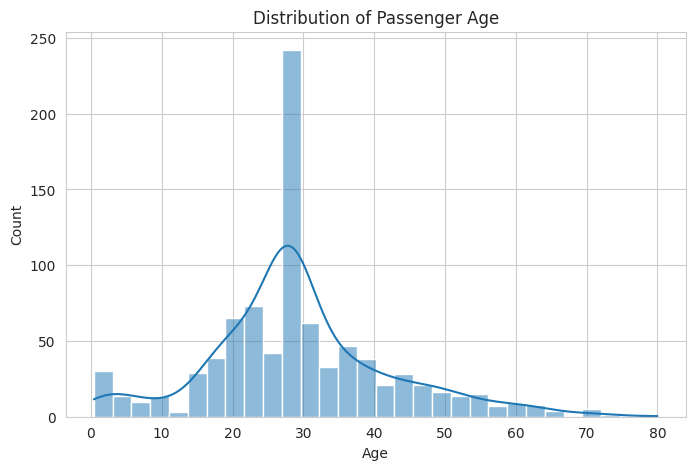

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(titanic['Age'], kde=True)
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

##Observation:
##Most passengers are between 20 and 40 years old.
##There are fewer very young children and older adults.

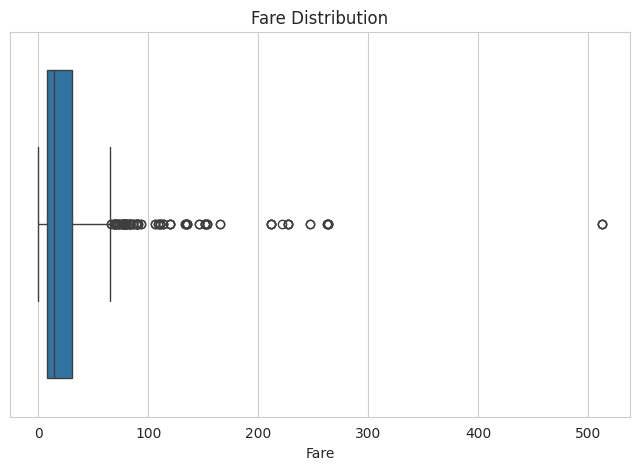

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x=titanic['Fare'])
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.show()


##Observation:
##There are several high fare outliers, meaning a few passengers paid much higher prices (likely 1st class luxury tickets).

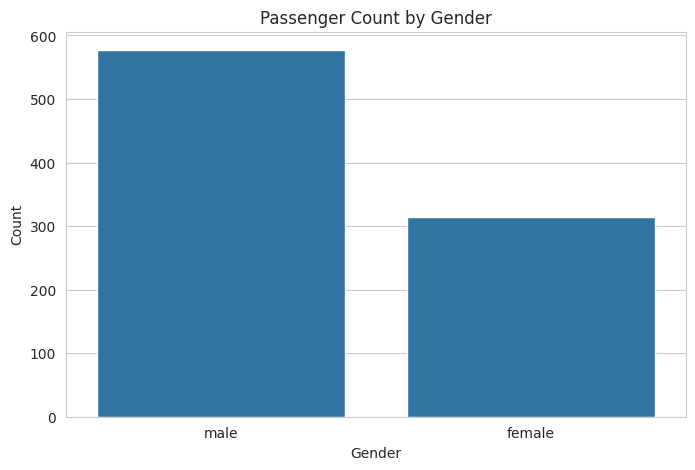

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sex', data=titanic)
plt.title("Passenger Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


##Observation:
##There are more male passengers than female passengers on board.

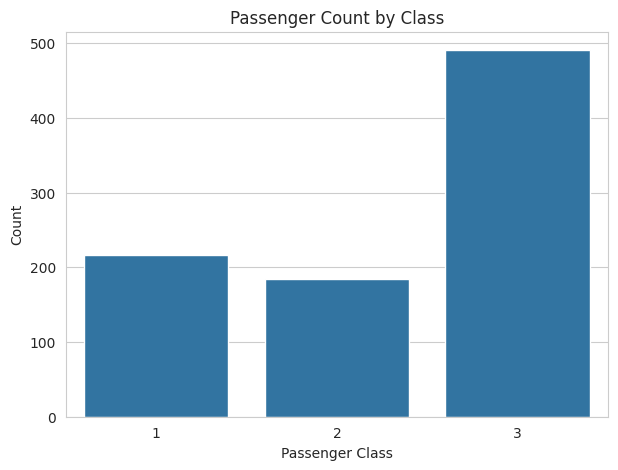

In [22]:
plt.figure(figsize=(7,5))
sns.countplot(x='Pclass', data=titanic)
plt.title("Passenger Count by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()


##Observation:
##3rd class has the highest number of passengers, followed by 1st and 2nd class.

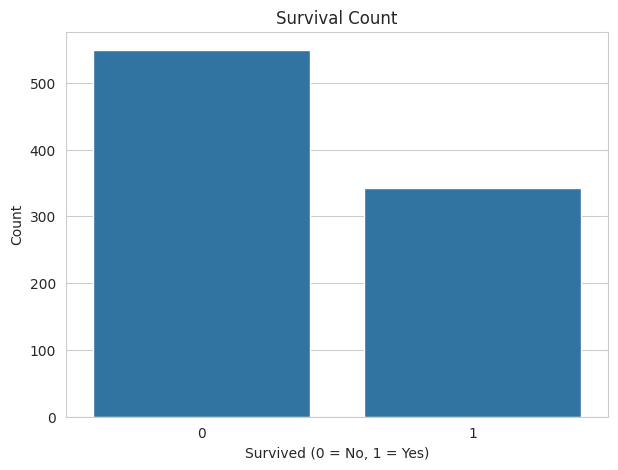

In [23]:
plt.figure(figsize=(7,5))
sns.countplot(x='Survived', data=titanic)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

##Observation:
##More passengers did not survive compared to those who survived.

In [ ]:
##---Part 4 — Bivariate Analysis
##Compare survival rate by gender using a bar plot.
##Compare survival rate by passenger class.
##Create a scatter plot of age vs fare, colored by survival.
##Investigate age distribution for survivors vs non-survivors using a KDE plot.

In [ ]:
titanic.head() ##first 5


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


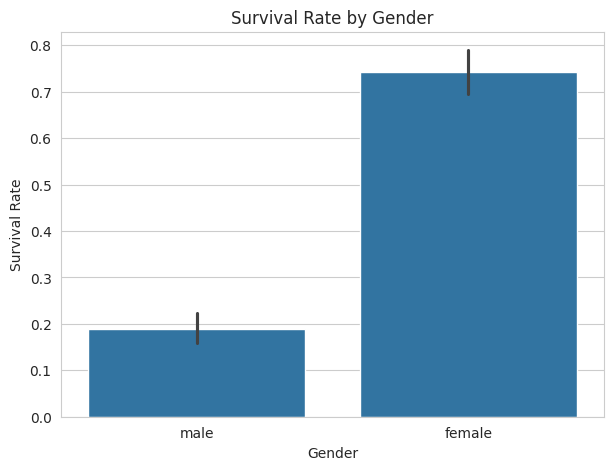

In [25]:
plt.figure(figsize=(7,5))
sns.barplot(x='Sex', y='Survived', data=titanic)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

##Interpretation:
##Females show a much higher survival rate compared to males.
##This suggests that “women and children first” was followed during evacuation.


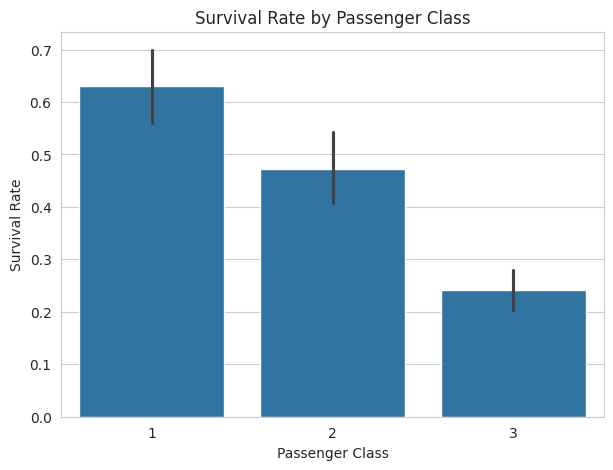

In [26]:
plt.figure(figsize=(7,5))
sns.barplot(x='Pclass', y='Survived', data=titanic)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

##Interpretation:
##1st class passengers had the highest survival rate, followed by 2nd class.
##3rd class passengers had the lowest survival rate — likely due to their cabins being located deeper in the ship and limited access to lifeboats.


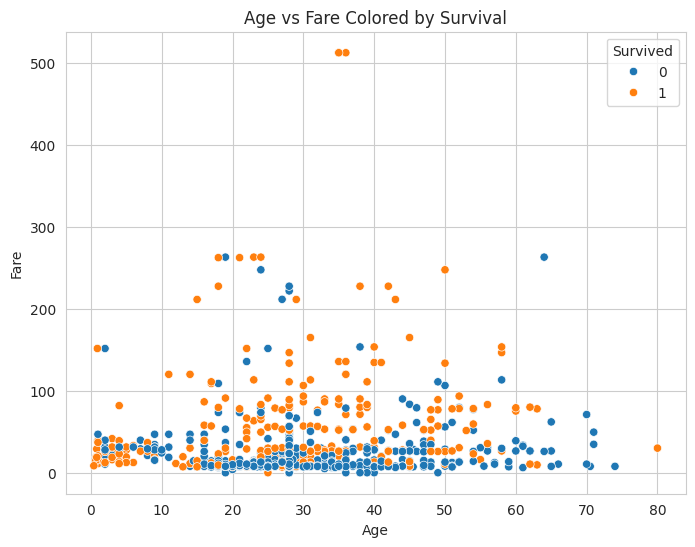

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=titanic)
plt.title("Age vs Fare Colored by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


##Interpretation:
##Many survivors cluster among passengers who paid higher fares (1st class).
##Survival does not show a strong pattern with age alone, but survivors tend to include those who paid more.

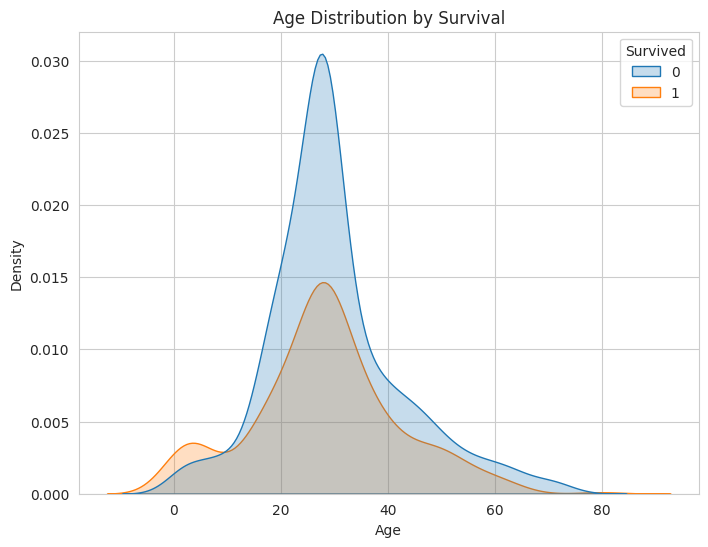

In [29]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=titanic, x='Age', hue='Survived', fill=True)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

##Interpretation:
##Survivors appear more concentrated in younger to middle-aged ranges, while non-survivors are more spread across ages.
##However, both groups have overlap — age alone was not the strongest deciding factor.


In [ ]:
##--Part 5— Feature Engineering
##Create a new feature is_child (1 if age < 12, else 0).
##Group by this feature and calculate average survival rate.
##Use your age_group and family_size features to find survival patterns.

In [31]:
titanic['is_child'] = titanic['Age'].apply(lambda x: 1 if x < 12 else 0)  ##Create is_child Feature

child_survival = titanic.groupby('is_child')['Survived'].mean().reset_index()
child_survival



,is_child,Survived
0,0,0.368165
1,1,0.573529


In [33]:
titanic['family_size'] = titanic['SibSp'] + titanic['Parch'] + 1  ##Create family_size Feature



##Create age_group Feature
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

titanic['age_group'] = pd.cut(titanic['Age'], bins=bins, labels=labels, right=False)


In [34]:
age_group_survival = titanic.groupby('age_group')['Survived'].mean().reset_index() ##Survival Patterns by age_group
age_group_survival


/tmp/ipython-input-263063392.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_survival = titanic.groupby('age_group')['Survived'].mean().reset_index() ##Survival Patterns by age_group


,age_group,Survived
0,Child,0.573529
1,Teen,0.488889
2,Young Adult,0.344383
3,Adult,0.416268
4,Senior,0.269231


In [35]:
family_survival = titanic.groupby('family_size')['Survived'].mean().reset_index()  ##Survival Patterns by family_size
family_survival


,family_size,Survived
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000
